# 4. Rispondere alle domande
Trasforma le seguenti richiesti in formule per estrarre infromazioni dal dataframe
- Mostrami le vendite maggiori di 10

- Mostrami i dati del 2018

- Mostrami le vendite maggiori di 13 e l'anno è il 2018

- Mostrami tutto TRANNE i casi in cui le vendite sono maggiori di 13 e l'anno è il 2018

- Mostrami i dati dove le vendite divise per 3 sono maggiori di 3

- Mostrami i dipendenti i cui nomi sono alfabeticamente dopo la J



In [21]:
import pandas as pd

sales = pd.DataFrame(
    data={
        "employee": [
            "Katrina",
            "Guanyu",
            "Jan",
            "Roman",
            "Jacqueline",
            "Paola",
            "Esperanza",
            "Alaina",
            "Egweyn",
        ],
        "sales": [14, 17, 6, 12, 8, 3, 7, 15, 5],
        "year": [2018, 2019, 2020, 2018, 2020, 2019, 2019, 2020, 2020],})
sales
print(f"Vendite maggiori di 10:\n{sales[sales["sales"]>10]}") 
print(f"Vendite dal 2018:\n{sales[sales["year"] == 2018]}") 
print(f"Vendite maggiori di 13 nel 2018:\n{sales[(sales["sales"]>13)&(sales["year"] == 2018)]}")
print(f"Vendite maggiori di 13 nel 2018:\n{sales[~((sales["sales"] > 13) & (sales["year"] == 2018))]}")
print(f"Vendite divise per 3 maggiori di 3:\n{sales[(sales["sales"]/3)>3]}")


Vendite maggiori di 10:
  employee  sales  year
0  Katrina     14  2018
1   Guanyu     17  2019
3    Roman     12  2018
7   Alaina     15  2020
Vendite dal 2018:
  employee  sales  year
0  Katrina     14  2018
3    Roman     12  2018
Vendite maggiori di 13 nel 2018:
  employee  sales  year
0  Katrina     14  2018
Vendite maggiori di 13 nel 2018:
     employee  sales  year
1      Guanyu     17  2019
2         Jan      6  2020
3       Roman     12  2018
4  Jacqueline      8  2020
5       Paola      3  2019
6   Esperanza      7  2019
7      Alaina     15  2020
8      Egweyn      5  2020
Vendite divise per 3 maggiori di 3:
  employee  sales  year
0  Katrina     14  2018
1   Guanyu     17  2019
3    Roman     12  2018
7   Alaina     15  2020


In [22]:
sales.query('employee > "J"')
print(f"Nomi alfebeticamente dopo j:\n{sales[sales["employee"] > "J"]}")

Nomi alfebeticamente dopo j:
     employee  sales  year
0     Katrina     14  2018
2         Jan      6  2020
3       Roman     12  2018
4  Jacqueline      8  2020
5       Paola      3  2019


# 5. Analisi di un dataset di video giochi
1. Quanti videogiochi sono stati pubblicati
2. Quali sono i generi più popolari? Mostralo con un bar plot
3. Plotta l'evoluzione del numero di giochi pubblicati nel tempo
4. Prova a riprodurre questo plot 

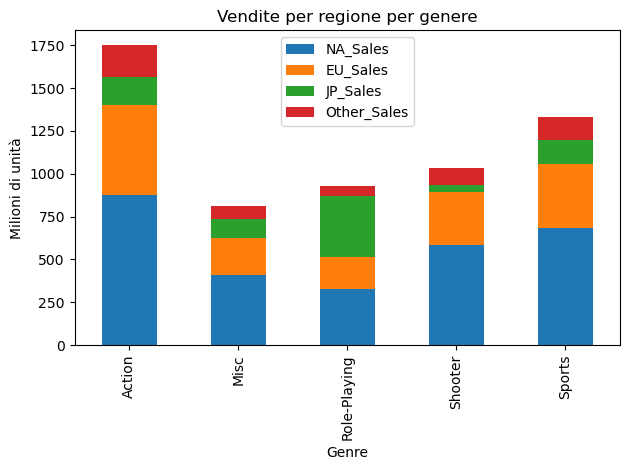


16598


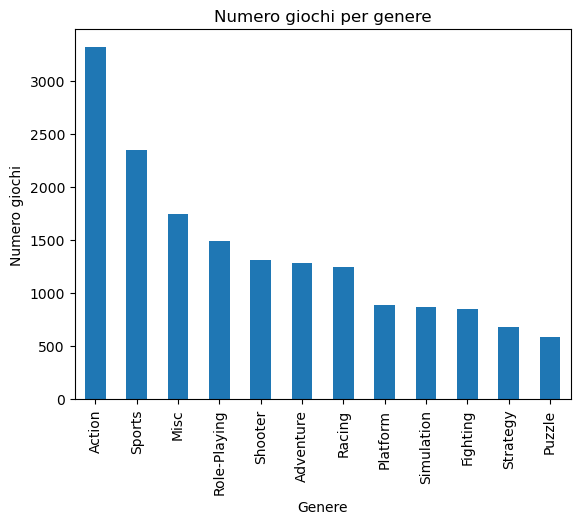

In [25]:
# Import dei pacchetti
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento del dataset
url = 'https://zenodo.org/record/5898311/files/vgsales.csv'
df = pd.read_csv(url)
df.head()
print(len(df)) #numero di videogiochi pubblicati
generi = df["Genre"].value_counts()#generi piu` popolari
generi.plot(kind="bar")
plt.title("Numero giochi per genere")
plt.xlabel("Genere")
plt.ylabel("Numero giochi")
plt.show()

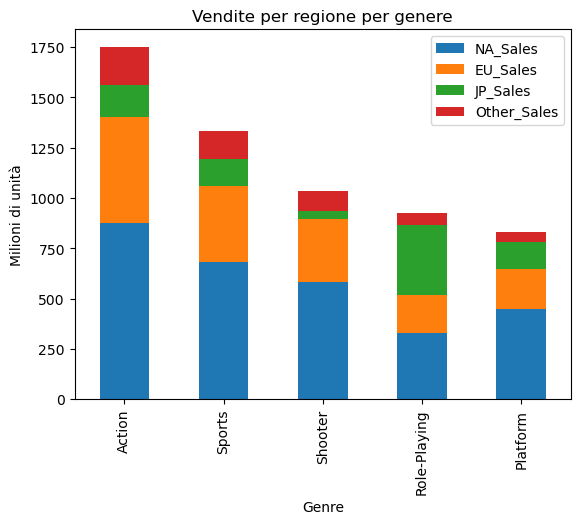

In [24]:
sales_genre = df.groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum() #somma delle vendite per genere
top5 = sales_genre.sum(axis=1).sort_values(ascending=False).head(5)
sales_top5 = sales_genre.loc[top5.index]# prendiamo i 5 generi piu` popolari
sales_top5.plot(kind="bar", stacked=True)
plt.title("Vendite per regione per genere")
plt.xlabel("Genre")
plt.ylabel("Milioni di unità")
plt.xticks(rotation=90)
plt.show()